# Homework 3
The purpose of the third homework is to become familiar with Ceteris Paribus (CP) and Partial Dependence profiles (PDP), and its variants like Accumulated Local Effects (ALE).

Take a model from HW3 (or any other) and calculate CP and PDP explanations. Write down some conclusions.

Focus on the presentation of results; for technical issues, seek support at Materials towards Homework 4: CP and PDP with XGBoost.

Submit the homework to this directory.

# Task 1
Consider a following model:

$f(x_1, x_2) = (x_1 + x_2)^2$

Assume that $x_1, x_2 \sim U[-1,1]$ and $x_1=x_2$ (full dependency).

Calculate PD profile for variable $x_1$ in this model.

Extra task if you do not fear conditional expected values: Calculate ME and ALE profiles for variable $x_1$ in this model.

## Solution
*PD (Partial Dependence):*

Density function of $x_2$ is $g(x_2) = \frac{1}{2} \mathbf{1}_{[-1,1]} $. As a result:
$$
g^{PD}_1(z) =
E_{x_2} f(z, x_2) =
E_{x_2} (z+x_2)^2 =
\int_{-1}^1 (z+x_2)^2  \frac{1}{2} \,d x_2 =
$$
$$
[\frac{ (z+x_2)^3 }{3}  \frac{1}{2}]_{x_2=-1}^{x_2=1} = \frac{(z+1)^3-(z-1)^3}{6} = \frac{1}{6}(6z^2 + 2) = z^2 + \frac{1}{3}
$$

*ME (Marginal Effects):*

Density function of $x_2|x_1=z$ is $g(x_2|x_1=z) = \mathbf{1}_{\{z\}}$. As a result:
$$
g^{ME}_1(z) = E_{x_2|x_1=z}f(z,x_2) = f(z,z) = 4z^2
$$

*ALE (Accumulated Local Effects)*

Again density function of $x_2|x_1=v$ is $g(x_2|x_1=v) = \mathbf{1}_{\{v\}}$. As a result:
$$
g^{AL}_{1}(z) =
\int_{-1}^z \left[E_{X_{-1}|x_1=v} \frac{\partial f(x)}{\partial x_1} \right] \,dv =
\int_{-1}^z \left[E_{X_{-1}|x_1=v} \frac{\partial (x_1 + x_2)^2}{\partial x_1} \right] \,dv =
$$

$$
\int_{-1}^z \left[E_{X_{-1}|x_1=v} 2(x_1+x_2) \right] \,dv =
\int_{-1}^z \left[E_{X_{-1}|x_1=v} 2(v+x_2) \right] \,dv =
$$
$$
\int_{-1}^z 4v \,dv = [2v^2]_{v=-1}^{v=z} = 2(z^2-1)
$$


# Task 2

## Results
**General setup**

In this task I used the model and dataset from HW1. The dataset is `phoneme.csv` and the trained model is CatBoost.

The model achieves an accuracy of 89%.

The dataset is highly imbalanced. The target variable takes values in ${1, 2}$, and the predictors are numerical features V1–V5. Using a LASSO model, I identified V4 as the most important variable and V3 as the second most important.

For the CP task, I selected two observations with indices 860 and 5390.
The model output is interpreted as the predicted probability of class 1.

***CP results***

![CP 5390 V3](images/cpo5390v3.png)
![CP 860 V3](images/cpo860v3.png)

![CP 5390 V4](images/cpo5390v4.png)
![CP 860 V4](images/cpo860v4.png)

The CP plots for V3 look similar across observations and generally increase with higher V3 values.
In contrast, the CP plots for V4 differ notably between observations.
This indicates that the model is nonlinear (as expected due to probability output) and, for V4, also non-monotonic.


***PDP results***


![PDP V3](images/pdpv3.png)
![PDP V4](images/pdpv4.png)

The PDP curves, computed as averages over the entire dataset, differ significantly from the CP plots for the selected observations. This suggests that other variables play an important interacting role.

Generally, for both V3 and V4, increases in the variable lead to decreasing predicted probability, although V3 shows notable exceptions.

***ME results***


![ME V3](images/mev3.png)
![ME V4](images/mev4.png)

ME values should theoretically be closer to the true local influence of each variable compared to PDP.
Indeed, the ME curves are even more nonlinear and differ from the PDP curves, indicating that the underlying feature distribution is not uniform.

***ALE results***


![ALE V3](images/alev3.png)
![ALE V4](images/alev4.png)

ALE values are centered at zero.
The ALE curves differ substantially from the CP, PDP, and ME results.
It is notable that ALE and ME differ, although for continuous distributions they should be similar. This may indicate non-continuity of the model, strong oscillations, or poor approximation due to limited data density in some regions.

## Appendix

In [56]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, precision_score, recall_score

from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

import os

In [57]:
os.makedirs("images", exist_ok=True) # We need folder for images

In [58]:
# 1) Take a model from HW3 (or any other). - I choose dataset and model from homework 1,
# Basic data preparation #
# I chose phoneme.csv cause it is one of smaller, only 5 useful columns + labels.
raw_data = pd.read_csv('phoneme.csv')
print("Head:\n", raw_data.head())
print("Are there any NaN values:", raw_data.isna().any().any())
print("Names of columns:", raw_data.columns)
data = raw_data.to_numpy()
print("Data as numpy:\n", data[:5,:])
print("Is first column of indexes:", (data[:,0] == np.arange(data.shape[0])).all())
# We can see that unnamed column is useless so we delete it.
data = data[:,1:]
print("Data without first column, 10 rows:\n", data[:5,:])
y = data[:,-1]
print("Categories in labels:", np.unique(y))
print("Nr of 1 category:", (y == 1).sum())
print("Nr of 2 category:", (y == 2).sum())
# As we can see there are only 2 categories.
X = data[:,:-1]
print("First 5 observations:\n", X[:5, :])
print("First 5 labels:\n", y[:5])
print("Observation dim:", X.shape)
print("Labels dim:", y.shape)
print("Observations dtype:", X.dtype)
print("Labels dtype:", y.dtype)

Head:
    Unnamed: 0        V1        V2        V3        V4        V5  TARGET
0           0  0.489927 -0.451528 -1.047990 -0.598693 -0.020418       1
1           1 -0.641265  0.109245  0.292130 -0.916804  0.240223       1
2           2  0.870593 -0.459862  0.578159  0.806634  0.835248       1
3           3 -0.628439 -0.316284  1.934295 -1.427099 -0.136583       1
4           4 -0.596399  0.015938  2.043206 -1.688448 -0.948127       1
Are there any NaN values: False
Names of columns: Index(['Unnamed: 0', 'V1', 'V2', 'V3', 'V4', 'V5', 'TARGET'], dtype='object')
Data as numpy:
 [[ 0.        0.489927 -0.451528 -1.04799  -0.598693 -0.020418  1.      ]
 [ 1.       -0.641265  0.109245  0.29213  -0.916804  0.240223  1.      ]
 [ 2.        0.870593 -0.459862  0.578159  0.806634  0.835248  1.      ]
 [ 3.       -0.628439 -0.316284  1.934295 -1.427099 -0.136583  1.      ]
 [ 4.       -0.596399  0.015938  2.043206 -1.688448 -0.948127  1.      ]]
Is first column of indexes: True
Data without first

In [59]:
# Training the model
y_binary = (y - 1).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

class_weights = [1.0, (y_binary == 0).sum() / (y_binary == 1).sum()]

cb = CatBoostClassifier(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1., 1.5],
    random_seed=42,
    verbose=100
)

cb.fit(X_train, y_train, eval_set=(X_val, y_val))

y_pred = cb.predict(X_val)
y_proba = cb.predict_proba(X_val)[:, 1] # Probability of result == 0

print("=== Metrics ===")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision (class 1):", precision_score(y_val, y_pred))
print("Recall (class 1):", recall_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

sample_obs = X_val[:5]
preds_prob = cb.predict_proba(sample_obs)[:, 0]
preds_class = cb.predict(sample_obs)

print("\nSample predictions (probabilities):", preds_prob)
print("Sample predictions (classes):", preds_class)
print("Sample labels:", y[:5])

0:	learn: 0.7720300	test: 0.7337110	best: 0.7337110 (0)	total: 6.91ms	remaining: 13.8s
100:	learn: 0.8722365	test: 0.8268215	best: 0.8286769 (99)	total: 762ms	remaining: 14.3s
200:	learn: 0.9041839	test: 0.8388106	best: 0.8396867 (195)	total: 1.43s	remaining: 12.8s
300:	learn: 0.9192919	test: 0.8405037	best: 0.8413866 (295)	total: 2.12s	remaining: 12s
400:	learn: 0.9338703	test: 0.8320935	best: 0.8422713 (311)	total: 2.71s	remaining: 10.8s
500:	learn: 0.9516971	test: 0.8375796	best: 0.8422713 (311)	total: 3.4s	remaining: 10.2s
600:	learn: 0.9637672	test: 0.8402556	best: 0.8422713 (311)	total: 3.96s	remaining: 9.21s
700:	learn: 0.9717485	test: 0.8375067	best: 0.8422713 (311)	total: 4.56s	remaining: 8.45s
800:	learn: 0.9800391	test: 0.8345865	best: 0.8422713 (311)	total: 5.14s	remaining: 7.69s
900:	learn: 0.9860003	test: 0.8354839	best: 0.8422713 (311)	total: 5.67s	remaining: 6.91s
1000:	learn: 0.9890024	test: 0.8336026	best: 0.8422713 (311)	total: 6.29s	remaining: 6.28s
1100:	learn: 0.9

In [60]:
# We assume that model result is probability of value 1, as all results belong to set {1,2}
def f(obs):
  return cb.predict_proba(obs)[:, 0]

# 2) Select two observations from the corresponding dataset.
np.random.seed(42)
rows = np.random.randint(X.shape[0], size=(2))
# print(X.shape)
print("Rows indices:", rows)
obs = X[rows, :]
preds = f(obs)
print("Observations:", obs)
print("True labels:", y[rows])
print("Predicted labels:", preds)
print("Predicted probabilities:", cb.predict_proba(obs))

Rows indices: [ 860 5390]
Observations: [[-0.753484 -0.701102  0.926483  0.871314 -0.136583]
 [-0.612399 -0.179619  0.029014  2.340936 -1.220216]]
True labels: [1. 2.]
Predicted labels: [0.74729492 0.07408718]
Predicted probabilities: [[0.74729492 0.25270508]
 [0.07408718 0.92591282]]


In [61]:
# 3) Calculate and plot Ceteris Paribus / ICE profiles for these observations (for selected/important variables).
# 3.1) We choose 2 most important variables - by using lasso model regularization:
def topk_indices(X, y, k=2, alpha_begin=0.1):
  assert 1 <= k and k <= X.shape[1]
  alpha = alpha_begin
  while True:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    if np.sum(np.abs(lasso.coef_) > 1e-6) == k:
      return alpha, lasso.coef_, lasso.intercept_
    elif np.sum(np.abs(lasso.coef_) > 1e-6) < k:
      alpha *= 0.5
    else:
      break
  # Right now alpha such that nr of non-zeros is higher than we want.
  prev_alpha = np.array([alpha,2*alpha])
  while True:
    alpha = 2*alpha # Equal to prev_alpha[1]
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    coefs = np.array(lasso.coef_)
    if np.sum(np.abs(coefs) > 1e-6) == k:
      return alpha, lasso.coef_, lasso.intercept_
    elif np.sum(np.abs(coefs) > 1e-6) < k:
      break
    else:
      prev_alpha = 2*prev_alpha

  while True:
    alpha = (prev_alpha[0] + prev_alpha[1])/2
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    coefs = np.array(lasso.coef_)
    if np.sum(np.abs(coefs) > 1e-6) == k:
      break
    elif np.sum(np.abs(coefs) > 1e-6) < k:
      prev_alpha[1] = alpha
    else:
      prev_alpha[0] = alpha
  return alpha, lasso.coef_, lasso.intercept_

alpha, coefs, bias = topk_indices(X, y, k=2)
print("Alpha:", alpha)
print("Coefficients:", coefs)
print("Bias:", bias)
indices = (np.abs(coefs) > 1e-6)*np.arange(X.shape[1])
mvv = indices[np.abs(coefs) > 1e-6]
print(f"{2} Most meaningful variables: {mvv}")
min_val = X[:,mvv].min(axis=0)
max_val = X[:,mvv].max(axis=0)
print(f"Min value of {mvv} variable: {min_val}")
print(f"Max value of {mvv} variable: {max_val}")

Alpha: 0.125
Coefficients: [-0.         -0.          0.01077278  0.02543345  0.        ]
Bias: 1.2934863066139164
2 Most meaningful variables: [2 3]
Min value of [2 3] variable: [-2.795869 -2.48534 ]
Max value of [2 3] variable: [2.630868 3.046948]


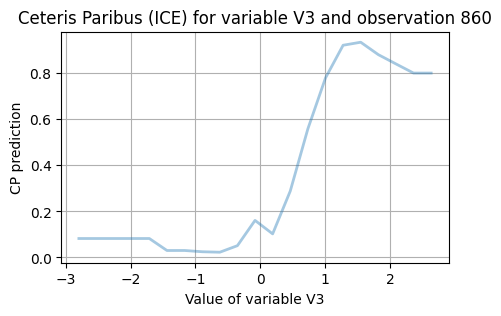

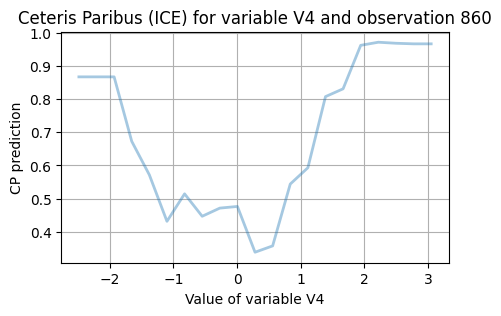

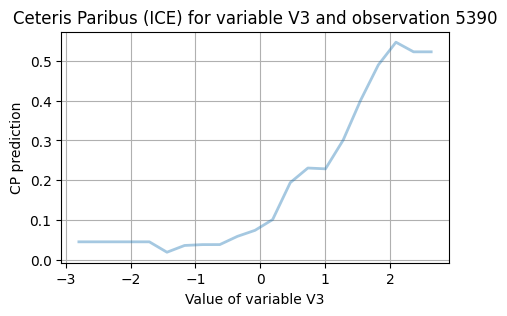

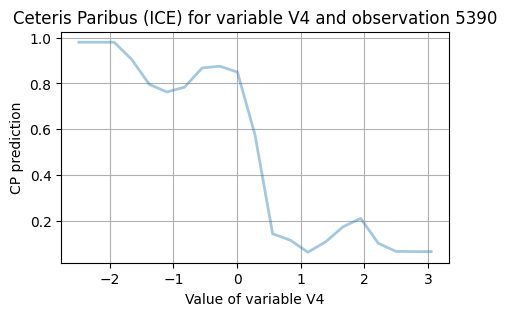

In [62]:
# 3.2) CP computation
# We can see that variable with id=3 (4-th column) is most important.
# With id=2 is second most important.
N = 21 # Samples differ on 3 variable by (max_val-min_val)/(N-1)
z_vals = np.linspace(min_val, max_val, N).T # Shape: (k,N+1)

def cp(z_vals, z_indices, obs):
  assert z_vals.shape[0] == z_indices.shape[0]
  o, m = obs.shape # o - nr of observations, m - nr of variables in each observation
  k, s = z_vals.shape # k - nr of important variables, s = nr of samples per variable
  result = np.zeros((o, k, s))
  for z_id in range(k):
    obs_copy = obs.copy()
    for j in range(s):
      obs_copy[:, z_indices[z_id]] = z_vals[z_id, j]
      result[:, z_id, j] = f(obs_copy)
  return result

cp_vals = cp(z_vals, mvv, obs)

for i in range(cp_vals.shape[0]):
  for j in range(cp_vals.shape[1]):
    plt.figure(figsize=(5,3))
    # plt.plot(z_vals[j], cp_vals[i,j], 'o')
    plt.plot(z_vals[j], cp_vals[i,j], alpha=0.4, linewidth=2)
    plt.xlabel(f"Value of variable V{mvv[j]+1}")
    plt.ylabel("CP prediction")
    plt.title(f"Ceteris Paribus (ICE) for variable V{mvv[j]+1} and observation {rows[i]}")
    plt.grid(True)
    plt.savefig(f"images/cpo{rows[i]}v{mvv[j]+1}.png", dpi=100)
    plt.show()

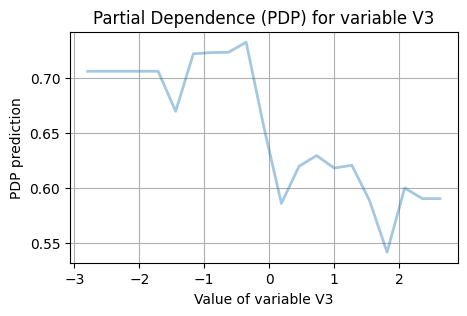

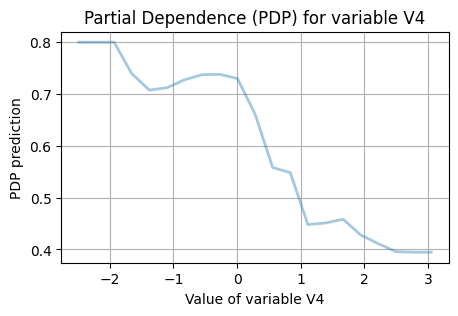

In [63]:
# 4) Implement PDP explanations and plot them for selected/important variables.
def pdp(z_vals, z_indices, data):
  assert z_vals.shape[0] == z_indices.shape[0]
  d, m = data.shape # o - nr of observations in dataset, m - nr of variables in each observation
  k, s = z_vals.shape # k - nr of important variables, s = nr of samples per variable
  result = np.zeros((k, s))
  for z_id in range(k):
    data_copy = data.copy()
    for j in range(s):
      data_copy[:, z_indices[z_id]] = z_vals[z_id, j]
      result[z_id, j] = f(data_copy).mean()
  return result

pdp_vals = pdp(z_vals, mvv, X)

for i in range(pdp_vals.shape[0]):
    plt.figure(figsize=(5,3))
    # plt.plot(z_vals[j], cp_vals[i], 'o')
    plt.plot(z_vals[i], pdp_vals[i], alpha=0.4, linewidth=2)
    plt.xlabel(f"Value of variable V{mvv[i]+1}")
    plt.ylabel("PDP prediction")
    plt.title(f"Partial Dependence (PDP) for variable V{mvv[i]+1}")
    plt.grid(True)
    plt.savefig(f"images/pdpv{mvv[i]+1}.png", dpi=100)
    plt.show()

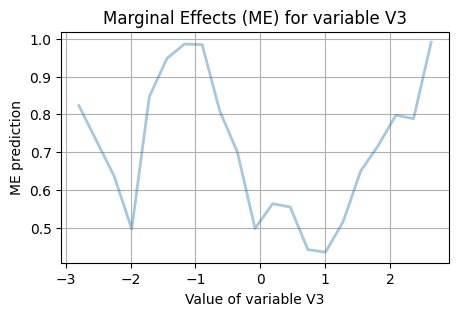

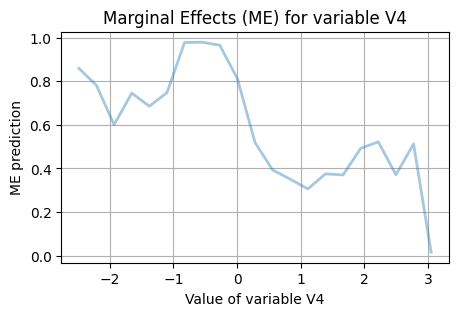

In [64]:
# 5) (bonus, ext extra points here) Implement ME or ALE explanations and plot them for selected/important variables.

# REMARK: Note that there is a problem of lack of observations for some given z. 
# This can be the case even if we divide domain of variable for small intervals [z_i, z_{i+1})
# and try to estimate E_{X^{-j|X_j \in [z_l, z_{l+1})}} assuming z \in [z_l, z_{l+1}).
# Indeed, there might not be any samples where x_j \in [z_l, z_{l+1}). Solution is to choose
# z values we are interested in more wisely. Let's assume that ~ X^{-j}|x_j=z_i is almost same as
# ~ X^{-j}|x_j \in [z_i,z_{i+1}), if none of samples are in interval [z_i,z_{i+1}) then we just
# get rid of variables z in z_vals. We know that first and last z in z_vals will stay, because some
# proper samples exists (we chose these z this way).

# 5.0) We compute z_vals according to remark above.
def fix_z_vals_list(z_vals, z_indices, data):
    k, s = z_vals.shape
    z_vals_list = z_vals.tolist()
    result = []
    for z_id in range(k):
        l_res = []
        for i in range(s-1):
            before = z_vals[z_id, i]
            after = z_vals[z_id, i+1]
            if np.any(np.logical_and(data[:,z_indices[z_id]] >= before, data[:, z_indices[z_id]] < after)):
                l_res.append(before)
        l_res.append(z_vals[z_id, -1])
        result.append(np.array(l_res))
    return result
    
z_vals_fixed = fix_z_vals_list(z_vals, mvv, X)
# print(f"z_vals.shape= {z_vals.shape}, z_vals_fixed lenghts for each row={[len(z_vals_fixed[0]), len(z_vals_fixed[1])]}")

# 5.1) ME implementation
def me(z_vals, z_indices, data):
  """
  We assume that for each list L of z_vals it has length >= 2, 
  each value is not smaller than previous value in L.
  """
  assert len(z_vals) == z_indices.shape[0]
  d, m = data.shape # o - nr of observations in dataset, m - nr of variables in each observation
  k = len(z_vals) # k - nr of important variables
  result = []
  for z_id in range(k):
    s = len(z_vals[z_id])
    l = []
    for j in range(s):
      before = z_vals[z_id][j]
      if j == s-1:
          after = z_vals[z_id][j]+1. # It does not matter what we add as long as it is positive
      else:
          after = z_vals[z_id][j+1]
      subset = data[np.logical_and(data[:,z_indices[z_id]] >= before, data[:, z_indices[z_id]] < after)].copy()
      subset[:, z_indices[z_id]] = z_vals[z_id][j]
      l.append(f(subset).mean())
    result.append(np.array(l))
  return result

me_vals = me(z_vals_fixed, mvv, X)
# print(me_vals)
# print("DEBUG, shapes:", me_vals[0].shape, me_vals[1].shape, z_vals_fixed[0].shape, z_vals_fixed[1].shape)

for i in range(len(me_vals)):
    plt.figure(figsize=(5,3))
    plt.plot(z_vals_fixed[i], me_vals[i], alpha=0.4, linewidth=2)
    plt.xlabel(f"Value of variable V{mvv[i]+1}")
    plt.ylabel("ME prediction")
    plt.title(f"Marginal Effects (ME) for variable V{mvv[i]+1}")
    plt.grid(True)
    plt.savefig(f"images/mev{mvv[i]+1}.png", dpi=100)
    plt.show()

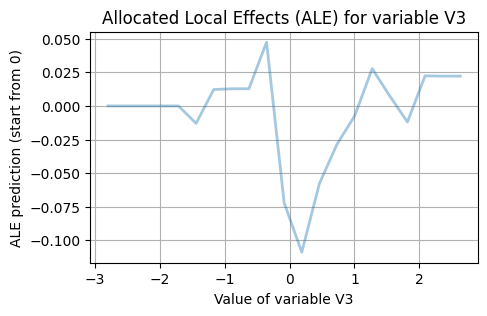

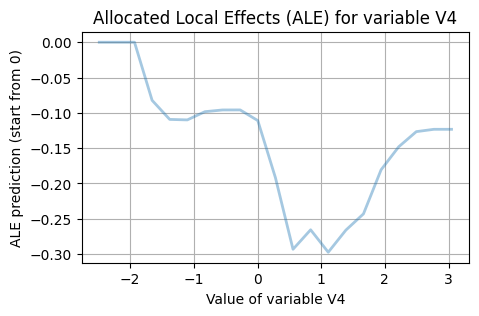

In [65]:
# 5.2) ALE implementationt
def ale(z_vals, z_indices, data):
  """
  We assume that for each list L of z_vals it has length >= 2, 
  each value is not smaller than previous value in L.
  """
  assert len(z_vals) == z_indices.shape[0]
  d, m = data.shape # o - nr of observations in dataset, m - nr of variables in each observation
  k = len(z_vals) # k - nr of important variables
  result = []
  for z_id in range(k):
    s = len(z_vals[z_id])
    l = [0]
    for j in range(s-1):
      before = z_vals[z_id][j]
      after = z_vals[z_id][j+1]
      subset = data[np.logical_and(data[:,z_indices[z_id]] >= before, data[:, z_indices[z_id]] < after)]
      higher = subset.copy()
      higher[:, z_indices[z_id]] = after
      lower = subset.copy()
      lower[:, z_indices[z_id]] = before
      diff = f(higher)-f(lower)
      l.append(diff.mean())
    result.append(np.array(l).cumsum())
  
  return result

ale_vals = ale(z_vals_fixed, mvv, X)

for i in range(len(ale_vals)):
    plt.figure(figsize=(5,3))
    plt.plot(z_vals_fixed[i], ale_vals[i], alpha=0.4, linewidth=2)
    plt.xlabel(f"Value of variable V{mvv[i]+1}")
    plt.ylabel("ALE prediction (start from 0)")
    plt.title(f"Allocated Local Effects (ALE) for variable V{mvv[i]+1}")
    plt.grid(True)
    plt.savefig(f"images/alev{mvv[i]+1}.png", dpi=100)
    plt.show()